# Lab №3 - Motion Trajectory Planning for a Manipulation Robot

### 0. Import the necessary libraries

In [710]:
from math import pi
import numpy as np
import roboticstoolbox as rtb
import matplotlib.pyplot as plt
import spatialmath.base as sb
from mpl_toolkits.mplot3d import Axes3D

### 1. Import the Stanford robot model

In [711]:
robot = rtb.models.DH.Stanford()
print(robot)

DHRobot: Stanford arm (by Victor Scheinman), 6 joints (RRPRRR), dynamics, standard DH parameters
┌────────┬───────┬────────┬────────┬─────────────────────┬────────┐
│   θⱼ   │  dⱼ   │   aⱼ   │   ⍺ⱼ   │         q⁻          │   q⁺   │
├────────┼───────┼────────┼────────┼─────────────────────┼────────┤
│  q1    │ 0.412 │      0 │ -90.0° │             -170.0° │ 170.0° │
│  q2    │ 0.154 │      0 │  90.0° │             -170.0° │ 170.0° │
│ -90.0° │    q3 │ 0.0203 │   0.0° │ 0.30479999999999996 │   1.27 │
│  q4    │     0 │      0 │ -90.0° │             -170.0° │ 170.0° │
│  q5    │     0 │      0 │  90.0° │              -90.0° │  90.0° │
│  q6    │     0 │      0 │   0.0° │             -170.0° │ 170.0° │
└────────┴───────┴────────┴────────┴─────────────────────┴────────┘

┌──┬──┐
└──┴──┘

┌──────┬─────┬─────┬────┬─────┬─────┬─────┐
│ name │ q0  │ q1  │ q2 │ q3  │ q4  │ q5  │
├──────┼─────┼─────┼────┼─────┼─────┼─────┤
│   qr │  0° │  0° │  0 │  0° │  0° │  0° │
│   qz │  0° │  0° │  0 │  0°

1. Let's define the mass of the links

In [712]:
# Masses (kg) - Approximated for Stanford arm
robot.links[0].m = 9.29    # Base
robot.links[1].m = 5.01    # Shoulder
robot.links[2].m = 4.25    # Elbow (prismatic joint)
robot.links[3].m = 1.08    # Wrist 1
robot.links[4].m = 0.63    # Wrist 2
robot.links[5].m = 0.51    # End-effector

2. Let's define the center of mass of each link

In [713]:
# Center of Mass (m) - Relative to link frames
robot.links[0].r = [0, 0, 0.1]          # Base CoM offset
robot.links[1].r = [0, -0.02, 0.12]     # Shoulder CoM
robot.links[2].r = [0, 0, 0.25]         # Elbow CoM (prismatic)
robot.links[3].r = [0, 0.01, 0.02]      # Wrist 1 CoM
robot.links[4].r = [0, 0, 0.01]         # Wrist 2 CoM
robot.links[5].r = [0, 0, 0.03]         # End-effector CoM

3. Let's define the inertia tensor of each link. Filling: [Lxx, Lyy, Lzz, Lxy, Lyz, Lxz]

In [714]:
# Inertia Tensors (kg·m²) - Diagonal approximations [Ixx, Iyy, Izz, Ixy, Iyz, Ixz]
robot.links[0].I = [0.1, 0.1, 0.05, 0, 0, 0]    # Base
robot.links[1].I = [0.05, 0.2, 0.15, 0, 0, 0]   # Shoulder
robot.links[2].I = [0.01, 0.01, 0.02, 0, 0, 0]  # Elbow
robot.links[3].I = [0.005, 0.003, 0.004, 0, 0, 0]  # Wrist 1
robot.links[4].I = [0.002, 0.002, 0.001, 0, 0, 0]  # Wrist 2
robot.links[5].I = [0.001, 0.001, 0.001, 0, 0, 0]  # End-effector

4. Let's set the moment of inertia of the drive

In [715]:
# Motor Inertia (kg·m²) - Typical servo values
robot.links[0].Jm = 0.0002    # Base motor
robot.links[1].Jm = 0.0002    # Shoulder motor
robot.links[2].Jm = 0.0001    # Elbow motor (prismatic)
robot.links[3].Jm = 0.00005   # Wrist 1 motor
robot.links[4].Jm = 0.00005   # Wrist 2 motor
robot.links[5].Jm = 0.00003   # End-effector motor

5. Let's define the coefficient of viscous friction of the drive

In [716]:
# Viscous Friction (N·m·s/rad)
robot.links[0].B = 0.01    # Base
robot.links[1].B = 0.008   # Shoulder
robot.links[2].B = 0.005   # Elbow
robot.links[3].B = 0.001   # Wrist 1
robot.links[4].B = 0.001   # Wrist 2
robot.links[5].B = 0.0005  # End-effector

6. Let's define the coefficient of Coulomb friction of the drive

In [717]:
# Coulomb Friction (N·m) - [T⁺, T⁻] for asymmetric friction
robot.links[0].Tc = [0.05, -0.06]   # Base
robot.links[1].Tc = [0.04, -0.05]   # Shoulder
robot.links[2].Tc = [0.02, -0.03]   # Elbow
robot.links[3].Tc = [0.01, -0.015]  # Wrist 1
robot.links[4].Tc = [0.01, -0.015]  # Wrist 2
robot.links[5].Tc = [0.005, -0.01]  # End-effector

7. Let's set the gear ratio for each link

In [718]:
# Gear Ratios (motor:joint)
robot.links[0].G = 120    # Base
robot.links[1].G = 100    # Shoulder
robot.links[2].G = 80     # Elbow
robot.links[3].G = 50     # Wrist 1
robot.links[4].G = 50     # Wrist 2
robot.links[5].G = 30     # End-effector

8. Let's set restrictions on the generalized coordinates for each link

In [719]:
# Joint Limits (radians)
robot.links[0].qlim = [-pi, pi]      # Base rotation
robot.links[1].qlim = [-pi, pi]      # Shoulder
robot.links[2].qlim = [0, 0.5]       # Elbow (prismatic, in meters)
robot.links[3].qlim = [-pi, pi]      # Wrist 1
robot.links[4].qlim = [-pi, pi]      # Wrist 2
robot.links[5].qlim = [-pi, pi]      # End-effector

### 2. Set the initial position of the robot and plot it

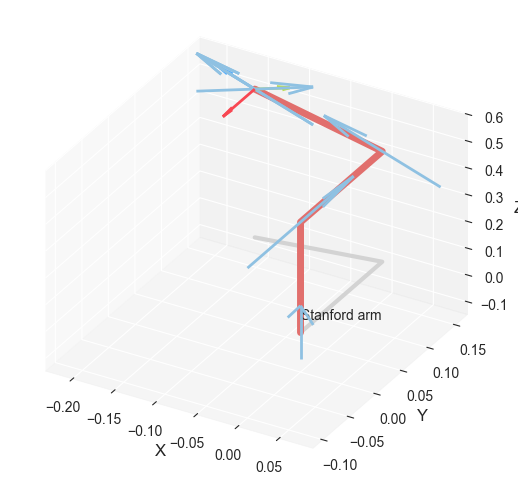

<Figure size 640x480 with 0 Axes>

In [720]:
q_start = [0, -pi/4, 0.2, 0, 0, 0]
robot.plot(q_start)
plt.show()

### 3. Solve the forward kinematics problem

In [733]:
T_start = robot.fkine(q_start)
print(T_start)

   0         0.7071   -0.7071   -0.1414    
  -1         0         0         0.1337    
   0         0.7071    0.7071    0.5534    
   0         0         0         1         



Visualize the workspace

In [722]:
n = 30  # Number of points along each axis  
i = 0  # Simple counter  

# Generate movement range for first 3 joints (between joint limits)
move = [np.linspace(robot.links[i].qlim[0], robot.links[i].qlim[1], n) for i in range(3)]  

# Initialize empty array for storing pose data (3D coordinates)
pose = np.zeros([3, n**3])  

Calculating the workspace

In [723]:
# Iterate through each point in the grid
for q1 in move[0]:
    for q2 in move[1]:
        for q3 in move[2]:
                Tt = robot.fkine([q1,q2,q3,0,0,0])  # Solve forward kinematics using only first 3 joint coordinates
                for j in range(3):
                    pose[j][i] = Tt.t[j]  # Store point coordinates
                i += 1

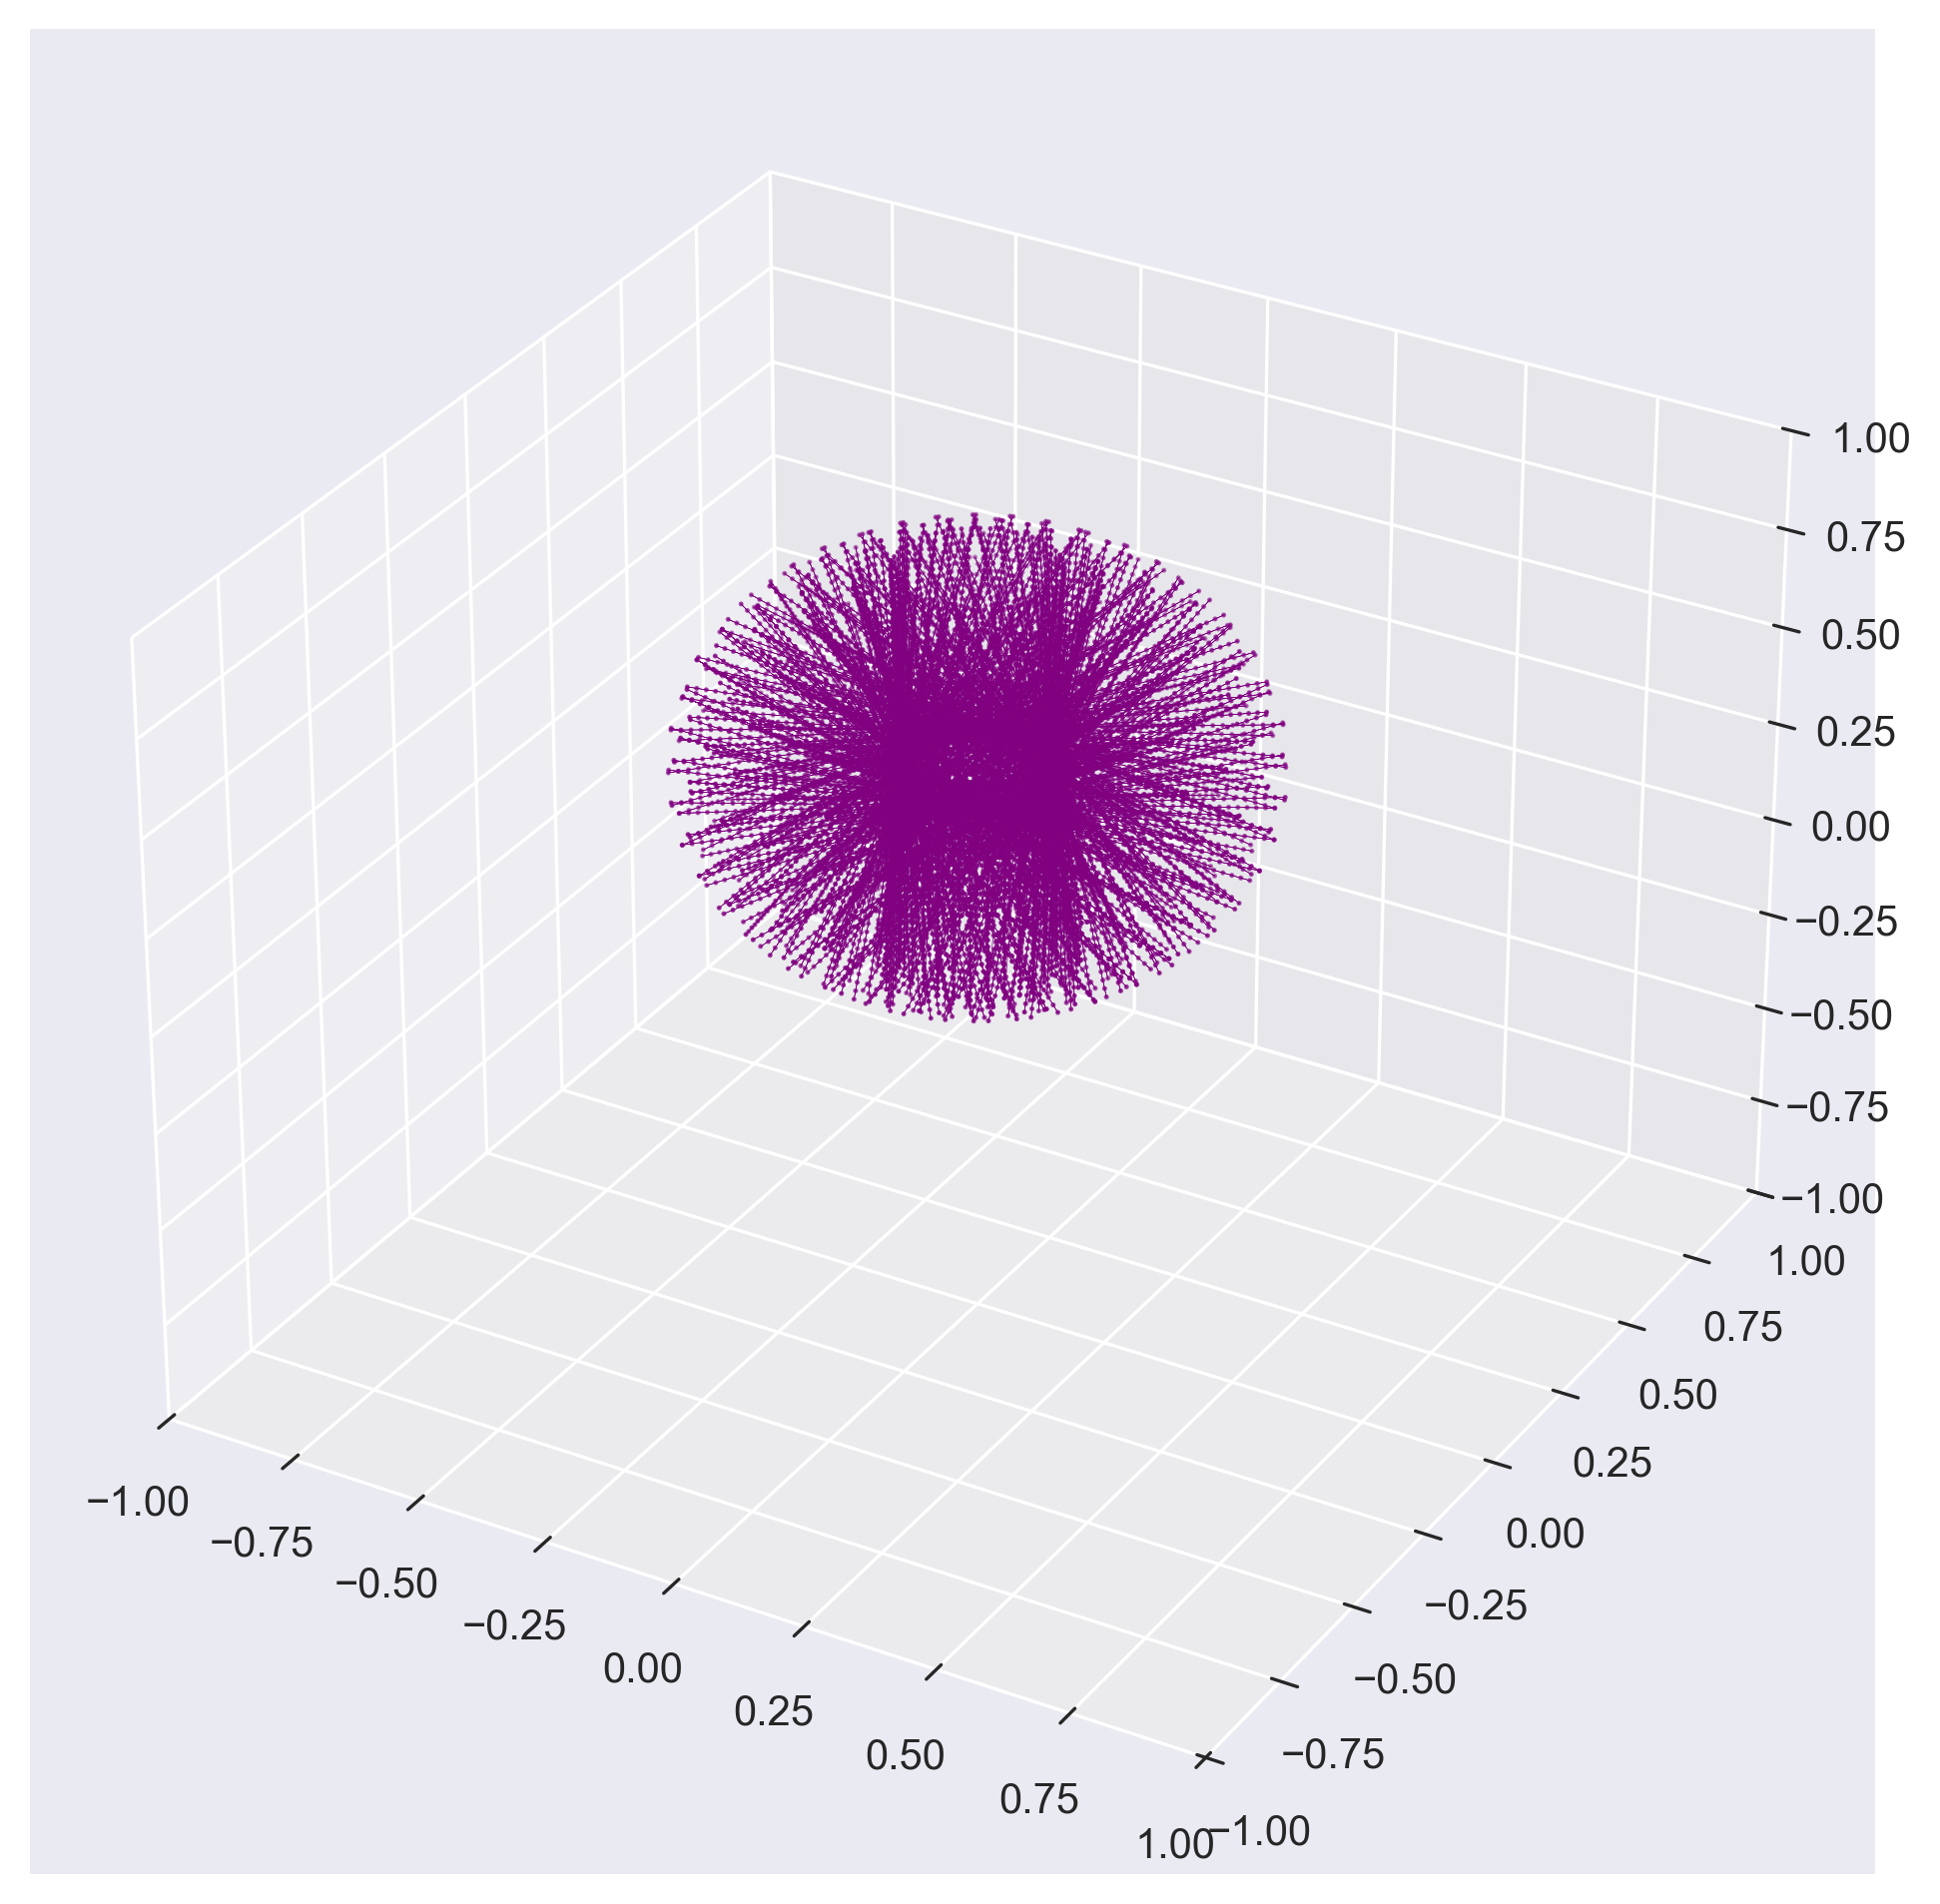

In [724]:
plt.figure(figsize=(8,8), dpi=300)
ax = plt.axes(projection="3d")
ax.plot3D(pose[0], pose[1], pose[2], color='Purple', linewidth=0.15)
ax.scatter3D(pose[0], pose[1], pose[2], s=0.5, color='Purple')
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
ax.set_zlim(-1,1)
plt.show()

### 4. Choosing Four Cartesian Points for the End-Effector

In [725]:
points = np.array([
    [0.5, -0.1, 0.1],  
    [0, 0.2, -0.2],   
    [0.7, 0.5, 0.2],   
    [0.1, -0.4, 0.7]   
])

### 5.  Calculating Inverse Kinematics for Each Point

In [726]:
joint_points = []
for p in points:
    T = sb.transl(p)  # translation only, no orientation change
    sol = robot.ikine_LM(T, q0=q_start)  # Levenberg-Marquardt IK solver, initial guess q_start
    if sol.success:
        joint_points.append(sol.q)
    else:
        raise RuntimeError(f"IK failed for point {p}")

joint_points = np.array(joint_points)
print("Joint angles for selected points:\n", joint_points)


Joint angles for selected points:
 [[-0.46270436 -1.00570322 -0.58263909  1.57079633  1.00570322  0.46270436]
 [ 0.83860636 -0.23842044 -0.62981609 -1.57079629 -0.23842044  2.30298626]
 [ 0.46419376 -1.32631032 -0.87582435  1.57079633  1.32631032 -0.46419377]
 [-1.65605773  0.934759    0.48483843  1.57079633 -0.934759    1.65605773]]


### 6. Define Motion Time and Cubic Polynomial Time Functions 

In [727]:
t_points = np.array([0, 3, 6, 9]) ## Define time stamps for the points

#Generate joint trajectories using cubic polynomial interpolation (jtraj)
N = 100  # number of trajectory points between each pair

# Interpolate joint trajectories between consecutive points
q_traj = []
qd_traj = []
qdd_traj = []
time_traj = []

for i in range(len(joint_points) - 1):
    t_segment = np.linspace(t_points[i], t_points[i+1], N)
    traj = rtb.jtraj(joint_points[i], joint_points[i+1], t_segment)
    q_traj.append(traj.q)
    qd_traj.append(traj.qd)
    qdd_traj.append(traj.qdd)
    time_traj.append(t_segment)

# Concatenate all segments
q_traj = np.vstack(q_traj)
qd_traj = np.vstack(qd_traj)
qdd_traj = np.vstack(qdd_traj)
time_traj = np.hstack(time_traj)

### 7. Plot Joint Positions, Velocities, Accelerations and Torques

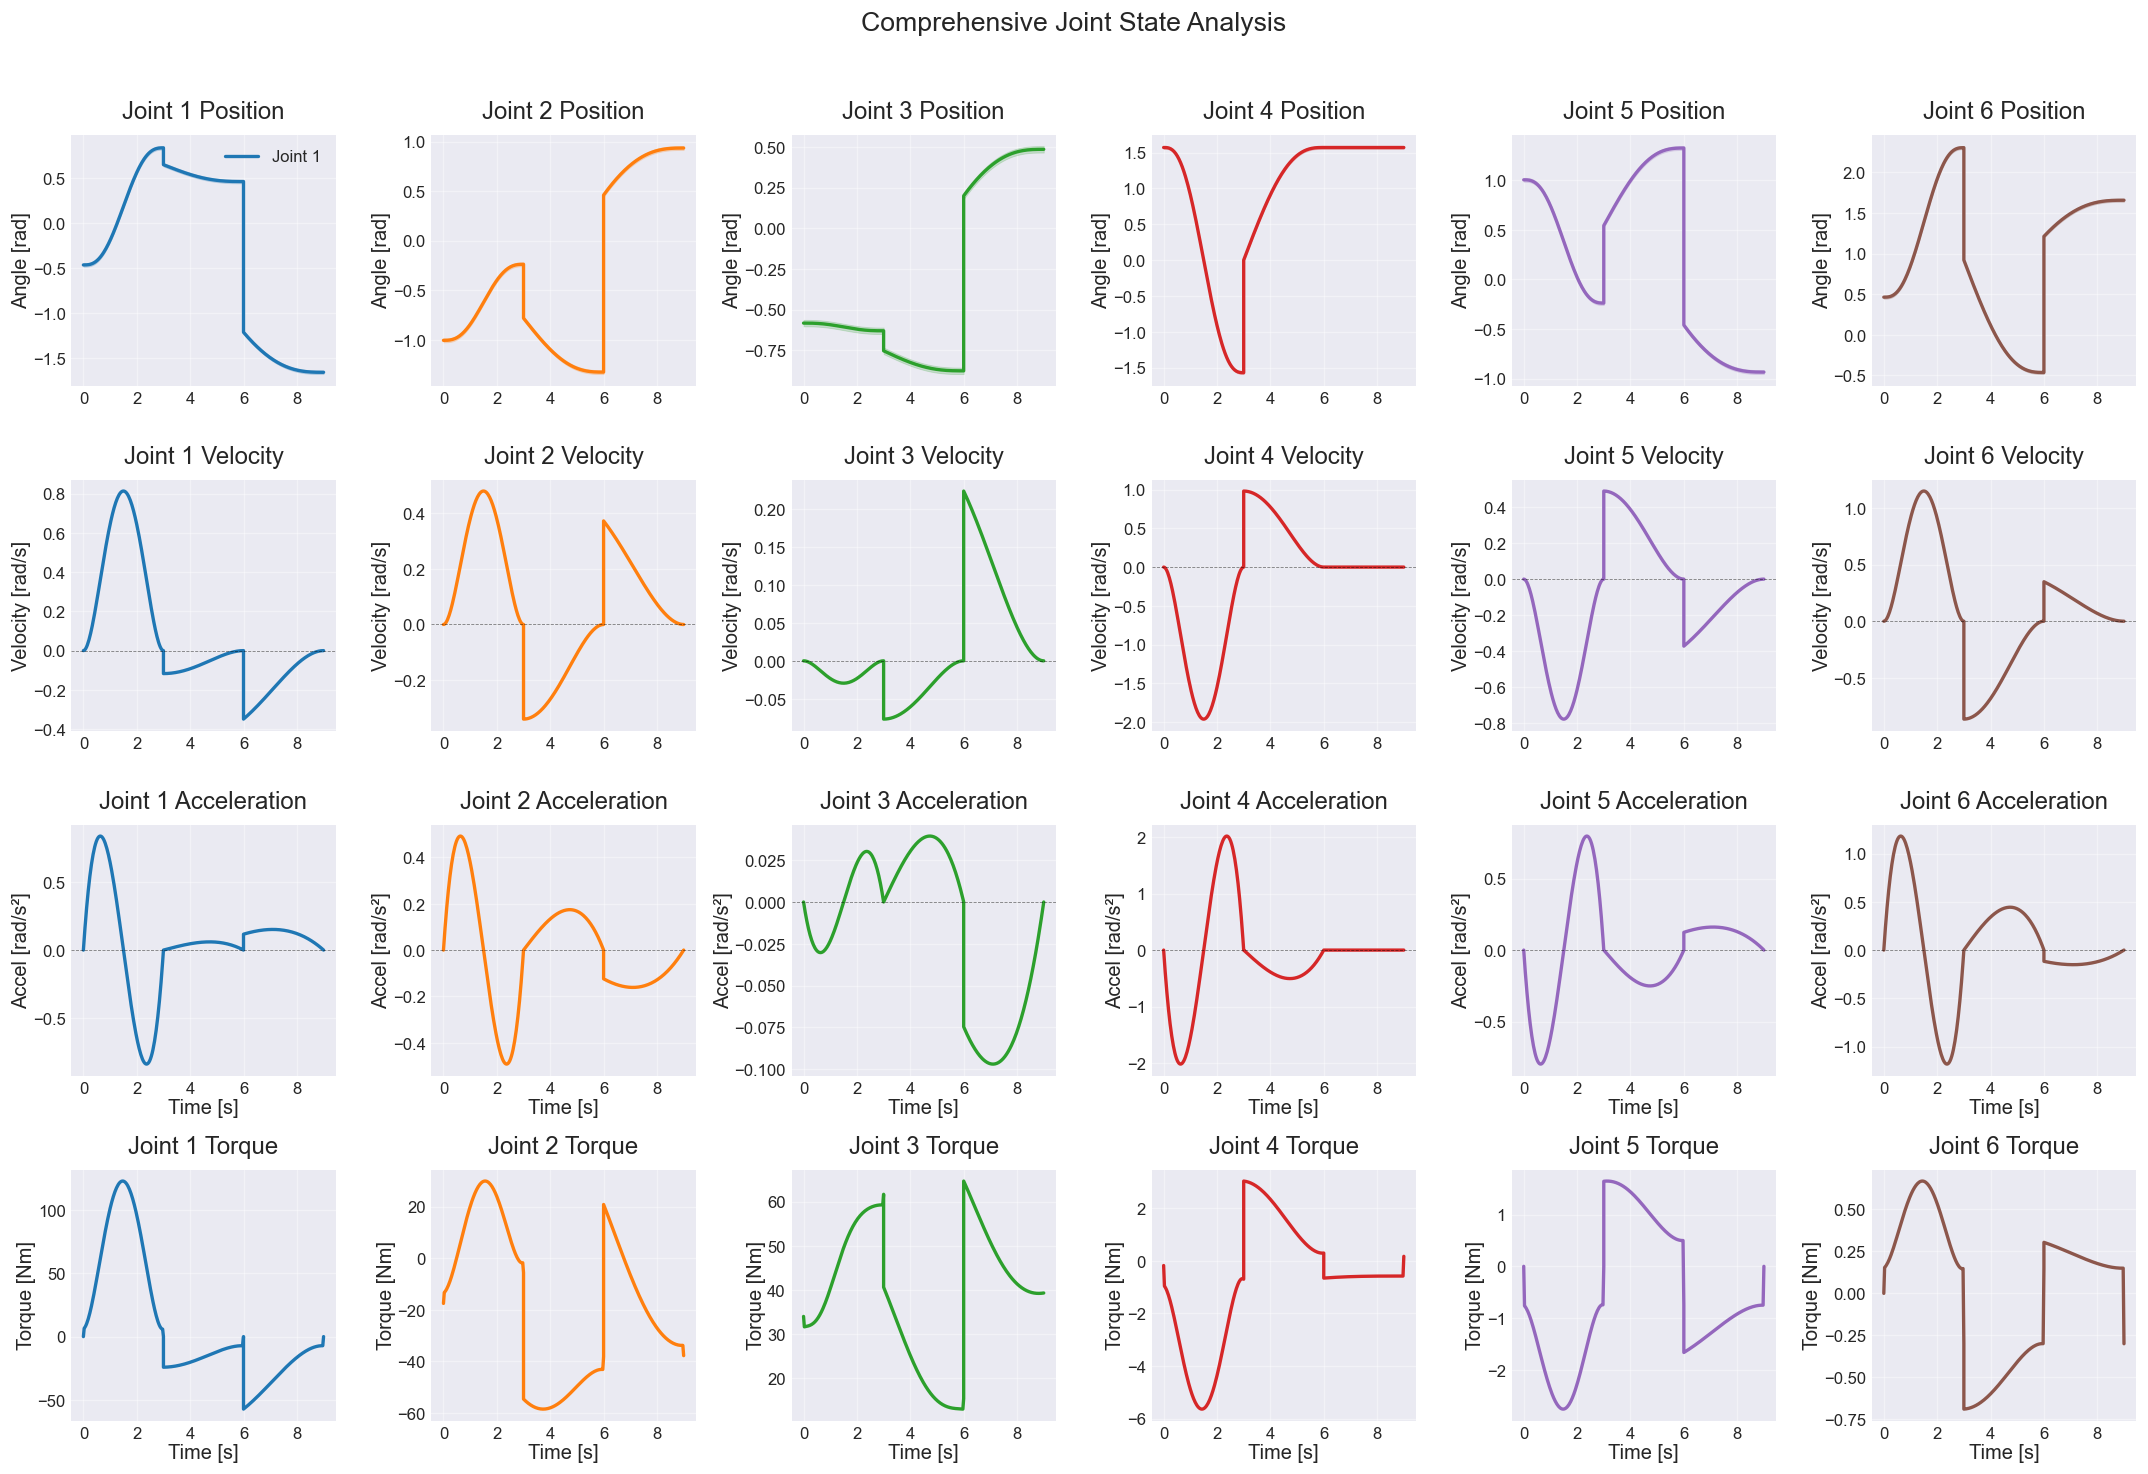

In [ ]:
# Set up professional style (with verified style name)
plt.style.use('seaborn-v0_8-darkgrid')  # Updated to valid style name
palette = plt.get_cmap('tab10')

# 1. Enhanced Joint States Plot
fig = plt.figure(figsize=(18, 12), dpi=120)

# Position Plots
for i in range(robot.n):
    ax = plt.subplot(4, robot.n, i+1)
    ax.plot(time_traj, q_traj[:, i], 
            color=palette(i), 
            linewidth=2,
            label=f'Joint {i+1}')
    ax.fill_between(time_traj, 
                   q_traj[:, i]-0.02, 
                   q_traj[:, i]+0.02,
                   alpha=0.2,
                   color=palette(i))
    ax.set_title(f'Joint {i+1} Position', pad=10)
    ax.set_ylabel('Angle [rad]')
    ax.grid(True, alpha=0.4)
    if i == 0:
        ax.legend(loc='upper right', framealpha=1)

# Velocity Plots
for i in range(robot.n):
    ax = plt.subplot(4, robot.n, robot.n + i + 1)
    ax.plot(time_traj, qd_traj[:, i], 
            color=palette(i), 
            linewidth=2)
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_title(f'Joint {i+1} Velocity', pad=10)
    ax.set_ylabel('Velocity [rad/s]')
    ax.grid(True, alpha=0.4)

# Acceleration Plots
for i in range(robot.n):
    ax = plt.subplot(4, robot.n, 2*robot.n + i + 1)
    ax.plot(time_traj, qdd_traj[:, i], 
            color=palette(i), 
            linewidth=2)
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_title(f'Joint {i+1} Acceleration', pad=10)
    ax.set_ylabel('Accel [rad/s²]')
    ax.set_xlabel('Time [s]')
    ax.grid(True, alpha=0.4)

# NEW: Torque Estimation Plot
for i in range(robot.n):
    ax = plt.subplot(4, robot.n, 3*robot.n + i + 1)
    torque = robot.rne(q_traj, qd_traj, qdd_traj)[:, i]
    ax.plot(time_traj, torque, 
            color=palette(i), 
            linewidth=2)
    ax.set_title(f'Joint {i+1} Torque', pad=10)
    ax.set_ylabel('Torque [Nm]')
    ax.set_xlabel('Time [s]')
    ax.grid(True, alpha=0.4)

plt.suptitle('Comprehensive Joint State Analysis', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()


### 8. Visualize End-Effector Trajectory in 3D

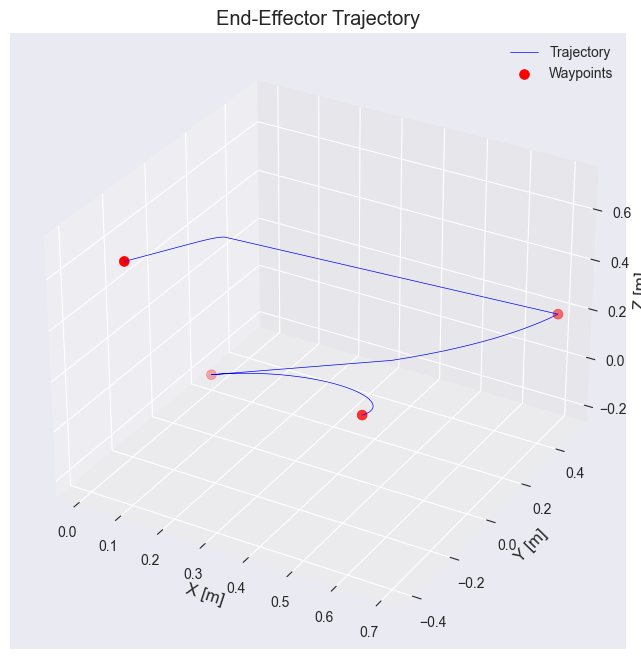

In [729]:
# Compute end-effector positions along the trajectory using forward kinematics
positions = np.array([robot.fkine(qi).t for qi in q_traj])

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(positions[:, 0], positions[:, 1], positions[:, 2], 'b-', label='Trajectory')
ax.scatter(points[:, 0], points[:, 1], points[:, 2], color='r', s=50, label='Waypoints')

ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.set_zlabel('Z [m]')
ax.set_title('End-Effector Trajectory')
ax.legend()
ax.grid(True)
plt.show()


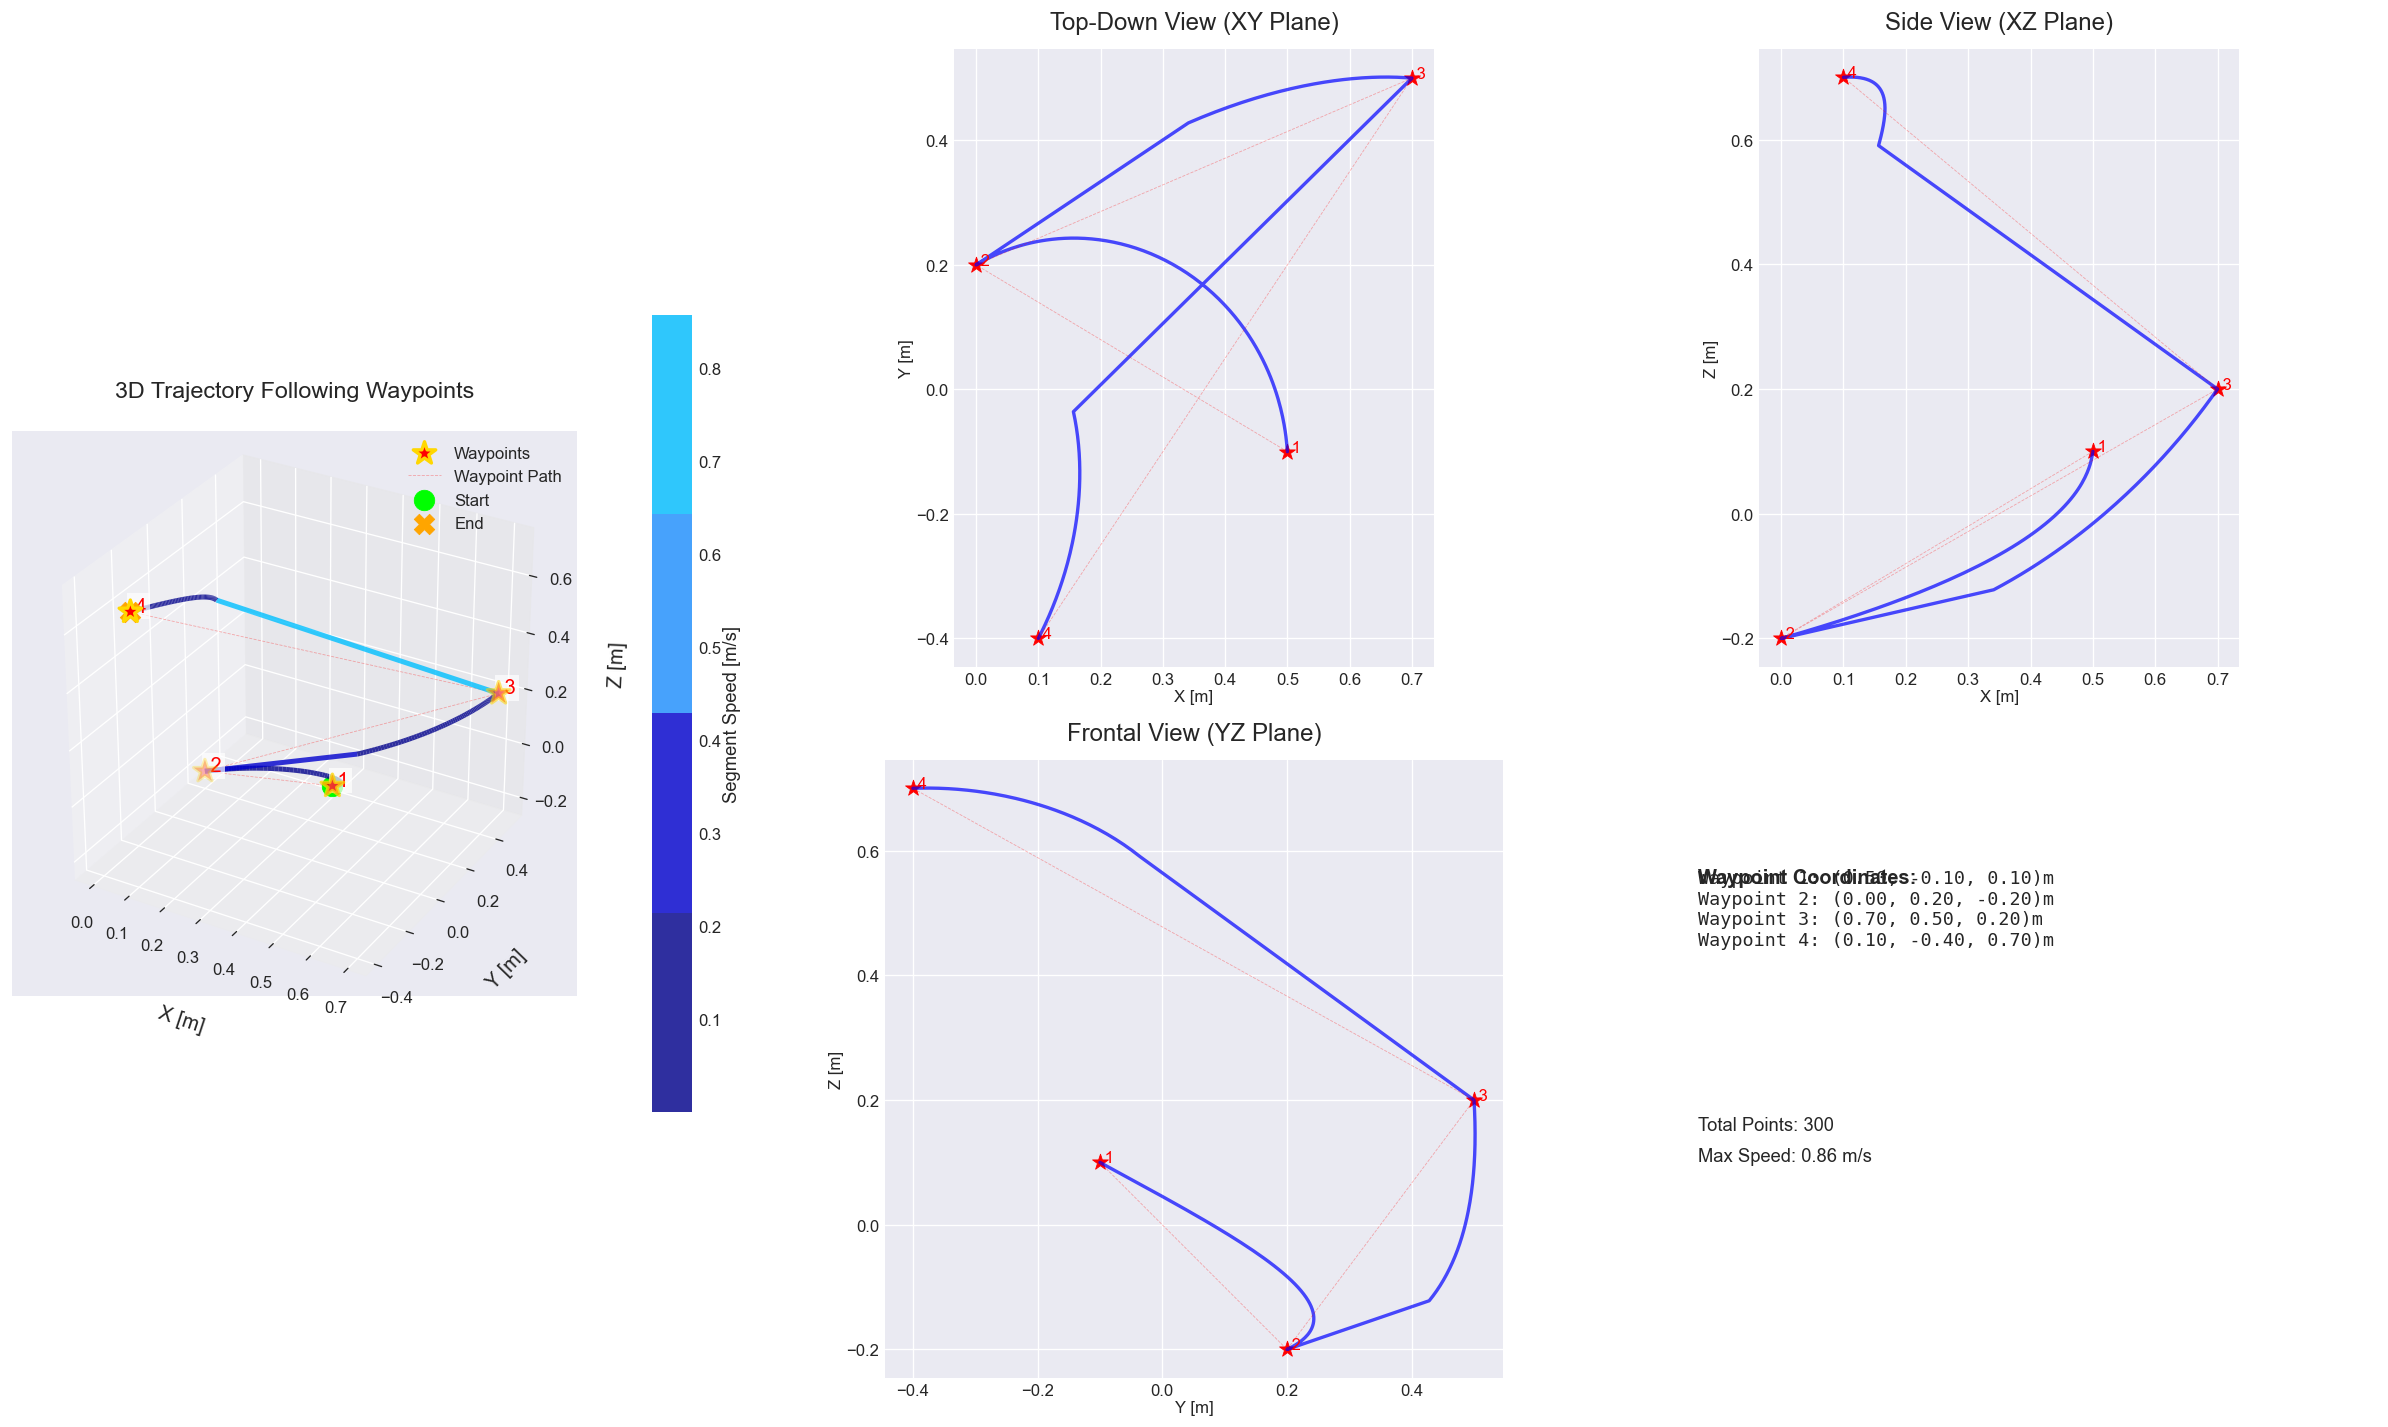

In [732]:
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.colors import ListedColormap
from matplotlib.gridspec import GridSpec

# Compute trajectory data
positions = np.array([robot.fkine(qi).t for qi in q_traj])
segments = np.array([positions[:-1], positions[1:]]).transpose(1,0,2)
speed = np.linalg.norm(np.diff(positions, axis=0), axis=1)
norm = plt.Normalize(speed.min(), speed.max())
cmap = ListedColormap(['darkblue', 'mediumblue', 'dodgerblue', 'deepskyblue'])

# Create figure with professional layout
plt.style.use('seaborn-v0_8-darkgrid')
fig = plt.figure(figsize=(20, 12), dpi=120)
gs = GridSpec(2, 3, figure=fig)  # 2 rows, 3 columns

# Main 3D View (top-left, spans 2 rows)
ax3d = fig.add_subplot(gs[:, 0], projection='3d')

# 2D Projection Views (right side)
ax_xy = fig.add_subplot(gs[0, 1])
ax_xz = fig.add_subplot(gs[0, 2])
ax_yz = fig.add_subplot(gs[1, 1])  # New YZ plane
ax_info = fig.add_subplot(gs[1, 2])  # For additional info

# 3D Trajectory Plot
lc = Line3DCollection(segments, cmap=cmap, norm=norm, linewidth=3, alpha=0.8)
lc.set_array(speed)
ax3d.add_collection3d(lc)

# Enhanced waypoints (3D)
wp = ax3d.scatter(points[:,0], points[:,1], points[:,2], 
                c='red', s=200, marker='*', edgecolor='gold',
                linewidth=2, label='Waypoints', zorder=10)

# Connection lines between waypoints (3D)
ax3d.plot(points[:,0], points[:,1], points[:,2], 
        'r--', alpha=0.3, label='Waypoint Path')

# Start/end markers (3D)
ax3d.scatter(positions[0,0], positions[0,1], positions[0,2], 
           c='lime', s=150, marker='o', label='Start')
ax3d.scatter(positions[-1,0], positions[-1,1], positions[-1,2], 
           c='orange', s=150, marker='X', label='End')

# XY Plane Projection
ax_xy.plot(positions[:,0], positions[:,1], c='b', linewidth=2, alpha=0.7)
ax_xy.scatter(points[:,0], points[:,1], c='red', s=100, marker='*')
ax_xy.plot(points[:,0], points[:,1], 'r--', alpha=0.3)
ax_xy.set_aspect('equal')
ax_xy.set_title('Top-Down View (XY Plane)', pad=12)
ax_xy.set_xlabel('X [m]', fontsize=10)
ax_xy.set_ylabel('Y [m]', fontsize=10)

# XZ Plane Projection
ax_xz.plot(positions[:,0], positions[:,2], c='b', linewidth=2, alpha=0.7)
ax_xz.scatter(points[:,0], points[:,2], c='red', s=100, marker='*')
ax_xz.plot(points[:,0], points[:,2], 'r--', alpha=0.3)
ax_xz.set_aspect('equal')
ax_xz.set_title('Side View (XZ Plane)', pad=12)
ax_xz.set_xlabel('X [m]', fontsize=10)
ax_xz.set_ylabel('Z [m]', fontsize=10)

# NEW: YZ Plane Projection
ax_yz.plot(positions[:,1], positions[:,2], c='b', linewidth=2, alpha=0.7)
ax_yz.scatter(points[:,1], points[:,2], c='red', s=100, marker='*')
ax_yz.plot(points[:,1], points[:,2], 'r--', alpha=0.3)
ax_yz.set_aspect('equal')
ax_yz.set_title('Frontal View (YZ Plane)', pad=12)
ax_yz.set_xlabel('Y [m]', fontsize=10)
ax_yz.set_ylabel('Z [m]', fontsize=10)

# Information Panel
ax_info.axis('off')
info_text = "\n".join([
    f"Waypoint {i+1}: ({p[0]:.2f}, {p[1]:.2f}, {p[2]:.2f})m"
    for i, p in enumerate(points)
])
ax_info.text(0.1, 0.8, "Waypoint Coordinates:", fontsize=12, weight='bold')
ax_info.text(0.1, 0.7, info_text, fontsize=11, family='monospace')
ax_info.text(0.1, 0.4, f"Total Points: {len(positions)}", fontsize=11)
ax_info.text(0.1, 0.35, f"Max Speed: {speed.max():.2f} m/s", fontsize=11)

# Professional formatting for 3D view
ax3d.set_xlabel('X [m]', fontsize=12, labelpad=15)
ax3d.set_ylabel('Y [m]', fontsize=12, labelpad=15)
ax3d.set_zlabel('Z [m]', fontsize=12, labelpad=15)
ax3d.set_title('3D Trajectory Following Waypoints', pad=20, fontsize=14)
ax3d.legend(loc='upper right', fontsize=10)
ax3d.grid(True, alpha=0.4)
ax3d.set_box_aspect([1, 1, 1])

# Add colorbar for velocity
cbar = fig.colorbar(lc, ax=ax3d, shrink=0.6, pad=0.1)
cbar.set_label('Segment Speed [m/s]', fontsize=11)

# Add connection numbers to all views
for i, (x,y,z) in enumerate(points):
    ax3d.text(x, y, z, f' {i+1}', fontsize=12, color='red',
             bbox=dict(facecolor='white', alpha=0.7, pad=2, edgecolor='none'))
    ax_xy.text(x, y, f' {i+1}', fontsize=10, color='red')
    ax_xz.text(x, z, f' {i+1}', fontsize=10, color='red')
    ax_yz.text(y, z, f' {i+1}', fontsize=10, color='red')

plt.tight_layout()
plt.show()

**Conclusion**

In this lab, a complete trajectory planning pipeline was developed for the Stanford manipulator. The task-space goals were defined as Cartesian positions, for which inverse kinematics (using the Levenberg-Marquardt method) successfully computed valid joint configurations.

Using these joint configurations, joint-space trajectories were generated with cubic polynomial interpolation (jtraj), and detailed plots of joint positions, velocities, accelerations, and required torques were produced.

Key findings:

The jtraj function generated smooth and continuous profiles for joint movement, ensuring feasible transitions between waypoints.

Velocity and acceleration plots showed expected smooth transitions, validating the trajectory’s continuity.

The torque profiles indicated moderate effort requirements, with no abrupt spikes, confirming the physical plausibility of the motion.